Part IV: VGG-13 Implementation

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile
from pathlib import Path

zip_path = Path("/content/cnn_dataset.zip")
extract_path = Path("/content/")

if zip_path.exists():
    print("Unzipping dataset")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset unzipped successfully!")
else:
    print("cnn_dataset.zip not found")


Unzipping dataset
Dataset unzipped successfully!


In [6]:
import os
import math
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedShuffleSplit
import zipfile

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {compute_device}")

dataset_root_path = Path("/content/cnn_dataset")
if not dataset_root_path.exists():
    raise FileNotFoundError("Dataset folder not found. Please check the extraction path.")

use_existing_split = (dataset_root_path / "train").exists()

input_image_size = 128
batch_size = 64
num_epochs = 16
initial_learning_rate = 0.01
momentum_value = 0.9
weight_decay_rate = 5e-4
num_data_workers = 4
validate_every_n_epochs = 1

best_model_weights_path = Path("/content/a2_part_4_weights.pkl")
training_curves_path = Path("/content/curves.png")
best_model_weights_path.parent.mkdir(parents=True, exist_ok=True)
training_curves_path.parent.mkdir(parents=True, exist_ok=True)
random_seed_value = 42

def set_random_seed(seed_value=random_seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.benchmark = True

set_random_seed()


PyTorch version: 2.8.0+cu126
CUDA available: True
Using device: cuda


In [7]:
#Loading the data
dataset_mean_std = (0.5, 0.5, 0.5)

training_transforms = transforms.Compose([
    transforms.Resize((input_image_size, input_image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

testing_transforms = transforms.Compose([
    transforms.Resize((input_image_size, input_image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

if use_existing_split:
    training_dataset = datasets.ImageFolder(dataset_root_path / "train", transform=training_transforms)
    validation_dataset = datasets.ImageFolder(dataset_root_path / "val", transform=testing_transforms) if (dataset_root_path / "val").exists() else None
    testing_dataset = datasets.ImageFolder(dataset_root_path / "test", transform=testing_transforms) if (dataset_root_path / "test").exists() else None

    if validation_dataset is None:
        print("No val/ folder found. Creating a 15% validation split from train/")
        train_targets = [label for _, label in datasets.ImageFolder(dataset_root_path / "train").imgs]
        stratified_splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=random_seed_value)
        all_indices = np.arange(len(train_targets))
        training_indices, validation_indices = next(stratified_splitter.split(all_indices, train_targets))

        base_training_folder = datasets.ImageFolder(dataset_root_path / "train", transform=training_transforms)
        base_validation_folder = datasets.ImageFolder(dataset_root_path / "train", transform=testing_transforms)

        training_dataset = Subset(base_training_folder, training_indices.tolist())
        validation_dataset = Subset(base_validation_folder, validation_indices.tolist())

        class_to_index = base_training_folder.class_to_idx
        class_names = list(class_to_index.keys())
    else:
        class_to_index = training_dataset.class_to_idx
        class_names = training_dataset.classes

    if testing_dataset is None:
        print("No test/ folder found. Using validation data as test data for now.")
        testing_dataset = validation_dataset
else:
    base_dataset = datasets.ImageFolder(dataset_root_path, transform=testing_transforms)
    class_names = base_dataset.classes
    all_labels = np.array([base_dataset.imgs[i][1] for i in range(len(base_dataset.imgs))])

    stratified_split_1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=random_seed_value)  # 70% train, 30% temp
    all_indices = np.arange(len(all_labels))
    training_indices, temp_indices = next(stratified_split_1.split(all_indices, all_labels))
    temp_labels = all_labels[temp_indices]

    stratified_split_2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=random_seed_value)
    validation_rel_indices, testing_rel_indices = next(stratified_split_2.split(np.arange(len(temp_indices)), temp_labels))

    validation_indices = temp_indices[validation_rel_indices]
    testing_indices = temp_indices[testing_rel_indices]

    training_dataset = Subset(datasets.ImageFolder(dataset_root_path, transform=training_transforms), training_indices.tolist())
    validation_dataset = Subset(datasets.ImageFolder(dataset_root_path, transform=testing_transforms), validation_indices.tolist())
    testing_dataset = Subset(datasets.ImageFolder(dataset_root_path, transform=testing_transforms), testing_indices.tolist())

print(f"Detected Classes ({len(class_names)}):", class_names)

training_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True, num_workers=num_data_workers, pin_memory=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=num_data_workers, pin_memory=True)
testing_loader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=False, num_workers=num_data_workers, pin_memory=True)


Detected Classes (36): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [8]:
#VGG-13 Implementation
vgg13_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']


class VGGNetwork(nn.Module):
    def __init__(self, feature_extractor, num_classes=10, dropout_rate=0.5, input_image_size=128):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.input_image_size = input_image_size

        flattened_feature_size = 512 * (input_image_size // (2 ** self._count_pool_layers(feature_extractor))) ** 2
        self.classifier_head = nn.Sequential(
            nn.Linear(flattened_feature_size, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(4096, num_classes),
        )

        self._initialize_model_weights()

    def _count_pool_layers(self, feature_extractor):
        """Counts how many MaxPool2d layers exist in the configuration."""
        return sum(1 for layer in feature_extractor if isinstance(layer, nn.MaxPool2d))

    def forward(self, input_tensor):
        """Defines the forward pass."""
        features_out = self.feature_extractor(input_tensor)
        flattened_out = torch.flatten(features_out, 1)
        predictions = self.classifier_head(flattened_out)
        return predictions

    def _initialize_model_weights(self):
        """Applies e and normal initializations to Conv and Linear layers."""
        for layer in self.modules():
            if isinstance(layer, nn.Conv2d):
                nn.init.kaiming_normal_(layer.weight, mode='fan_out', nonlinearity='relu')
                if layer.bias is not None:
                    nn.init.constant_(layer.bias, 0)
            elif isinstance(layer, nn.Linear):
                nn.init.normal_(layer.weight, 0, 0.01)
                nn.init.constant_(layer.bias, 0)


def create_vgg_layers(configuration, input_channels=3, apply_padding=True):
    """Creates convolutional and pooling layers as per configuration list."""
    layer_blocks = []
    for layer_value in configuration:
        if layer_value == 'M':
            layer_blocks.append(nn.MaxPool2d(kernel_size=2, stride=2))
        else:
            padding_value = 1 if apply_padding else 0
            conv_layer = nn.Conv2d(input_channels, layer_value, kernel_size=3, padding=padding_value)
            layer_blocks.extend([conv_layer, nn.ReLU(inplace=True)])
            input_channels = layer_value
    return nn.Sequential(*layer_blocks)


#Building the model
number_of_classes = len(class_names)
feature_layers = create_vgg_layers(vgg13_config, input_channels=3, apply_padding=True)

vgg13_model = VGGNetwork(
    feature_extractor=feature_layers,
    num_classes=number_of_classes,
    dropout_rate=0.5,
    input_image_size=input_image_size
).to(compute_device)
amp_gradient_scaler = torch.cuda.amp.GradScaler(enabled=(compute_device.type == 'cuda'))
sum(p.numel() for p in vgg13_model.parameters()) / 1e6


/tmp/ipython-input-4262294924.py:71: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_gradient_scaler = torch.cuda.amp.GradScaler(enabled=(compute_device.type == 'cuda'))


59.892324

In [9]:
#Optimizer and learning rate scheduler

vgg13_optimizer = torch.optim.SGD(
    vgg13_model.parameters(),
    lr=initial_learning_rate,
    momentum=momentum_value,
    weight_decay=weight_decay_rate,
    nesterov=False
)

#learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    vgg13_optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

#defining loss function
loss_function = nn.CrossEntropyLoss()


In [10]:
#training loop
def execute_epoch(data_loader, is_training=True):
    """Runs one complete epoch for training or validation."""
    vgg13_model.train(mode=is_training)
    total_epoch_loss, total_correct_predictions, total_samples = 0.0, 0, 0

    for (input_images, target_labels) in data_loader:
        input_images, target_labels = (
            input_images.to(compute_device, non_blocking=True),
            target_labels.to(compute_device, non_blocking=True),
        )

        if is_training:
            vgg13_optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(compute_device.type == "cuda")):
                output_logits = vgg13_model(input_images)
                batch_loss = loss_function(output_logits, target_labels)
            amp_gradient_scaler.scale(batch_loss).backward()
            amp_gradient_scaler.step(vgg13_optimizer)
            amp_gradient_scaler.update()
        else:
            with torch.no_grad():
                output_logits = vgg13_model(input_images)
                batch_loss = loss_function(output_logits, target_labels)

        predicted_labels = output_logits.argmax(dim=1)
        total_samples += target_labels.size(0)
        total_correct_predictions += (predicted_labels == target_labels).sum().item()
        total_epoch_loss += batch_loss.item() * target_labels.size(0)

    average_loss = total_epoch_loss / total_samples
    accuracy_score = total_correct_predictions / total_samples
    return average_loss, accuracy_score

training_progress = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": [],
}

best_validation_accuracy = 0.0

for current_epoch in range(1, num_epochs + 1):
    train_loss, train_accuracy = execute_epoch(training_loader, is_training=True)
    val_loss, val_accuracy = execute_epoch(validation_loader, is_training=False)

    lr_scheduler.step(val_loss)

    training_progress["train_loss"].append(train_loss)
    training_progress["train_accuracy"].append(train_accuracy)
    training_progress["val_loss"].append(val_loss)
    training_progress["val_accuracy"].append(val_accuracy)
    training_progress["learning_rate"].append(vgg13_optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {current_epoch:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} acc={train_accuracy*100:.2f}% | "
        f"val_loss={val_loss:.4f} acc={val_accuracy*100:.2f}% | "
        f"lr={vgg13_optimizer.param_groups[0]['lr']:.5f}"
    )

    if val_accuracy > best_validation_accuracy:
        best_validation_accuracy = val_accuracy
        torch.save(
            {
                "model_state": vgg13_model.state_dict(),
                "meta": {
                    "num_classes": number_of_classes,
                    "input_size": input_image_size,
                    "classes": class_names,
                },
            },
            best_model_weights_path,
        )
        print(f"Saved best weights to {best_model_weights_path} (val_acc={val_accuracy*100:.2f}%)")

print("Best validation accuracy:", best_validation_accuracy)


/tmp/ipython-input-2488653406.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(compute_device.type == "cuda")):


Epoch 01/16 | train_loss=1.2337 acc=62.62% | val_loss=0.4099 acc=85.58% | lr=0.01000
Saved best weights to /content/a2_part_4_weights.pkl (val_acc=85.58%)
Epoch 02/16 | train_loss=0.4090 acc=85.54% | val_loss=0.3374 acc=87.35% | lr=0.01000
Saved best weights to /content/a2_part_4_weights.pkl (val_acc=87.35%)
Epoch 03/16 | train_loss=0.3379 acc=87.85% | val_loss=0.3026 acc=88.96% | lr=0.01000
Saved best weights to /content/a2_part_4_weights.pkl (val_acc=88.96%)
Epoch 04/16 | train_loss=0.3050 acc=88.68% | val_loss=0.2674 acc=89.97% | lr=0.01000
Saved best weights to /content/a2_part_4_weights.pkl (val_acc=89.97%)
Epoch 05/16 | train_loss=0.2859 acc=89.26% | val_loss=0.2790 acc=89.50% | lr=0.01000
Epoch 06/16 | train_loss=0.2694 acc=89.93% | val_loss=0.2760 acc=89.81% | lr=0.01000
Epoch 07/16 | train_loss=0.2567 acc=90.26% | val_loss=0.2598 acc=90.11% | lr=0.01000
Saved best weights to /content/a2_part_4_weights.pkl (val_acc=90.11%)
Epoch 08/16 | train_loss=0.2483 acc=90.38% | val_loss=0

Saved accuracy curves to /content/curves.png


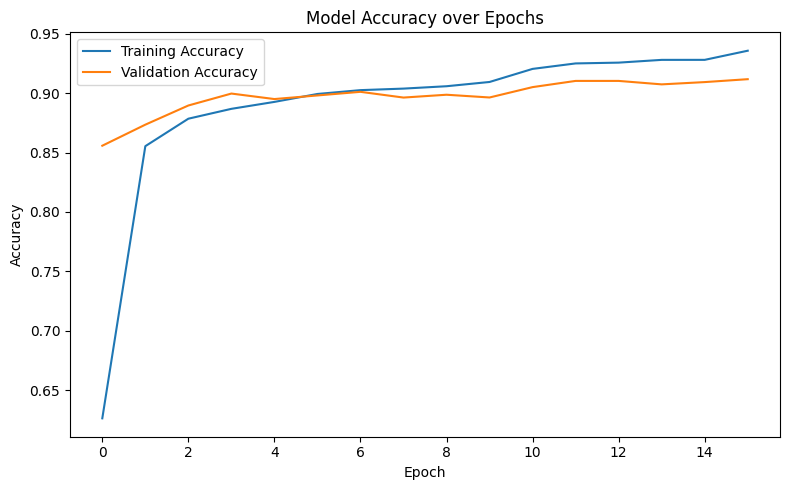

In [11]:
#Plotting the training curves
plt.figure(figsize=(8, 5))
plt.plot(training_progress["train_accuracy"], label="Training Accuracy")
plt.plot(training_progress["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy over Epochs")
plt.legend()
plt.tight_layout()
plt.savefig(training_curves_path, dpi=150)
print(f"Saved accuracy curves to {training_curves_path}")
plt.show()

TEST ACCURACY: 91.37%
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.76      0.71       420
           1       0.52      0.89      0.65       420
           2       0.91      0.87      0.89       420
           3       0.97      0.96      0.97       420
           4       0.95      0.95      0.95       420
           5       0.96      0.92      0.94       420
           6       0.96      0.98      0.97       420
           7       0.96      0.98      0.97       420
           8       0.99      0.99      0.99       420
           9       0.92      0.95      0.93       420
           A       0.99      0.99      0.99       420
           B       0.99      1.00      0.99       420
           C       0.97      0.97      0.97       420
           D       0.94      0.94      0.94       420
           E       0.97      0.97      0.97       420
           F       0.98      0.97      0.97       420
           G       0.96      0.94  

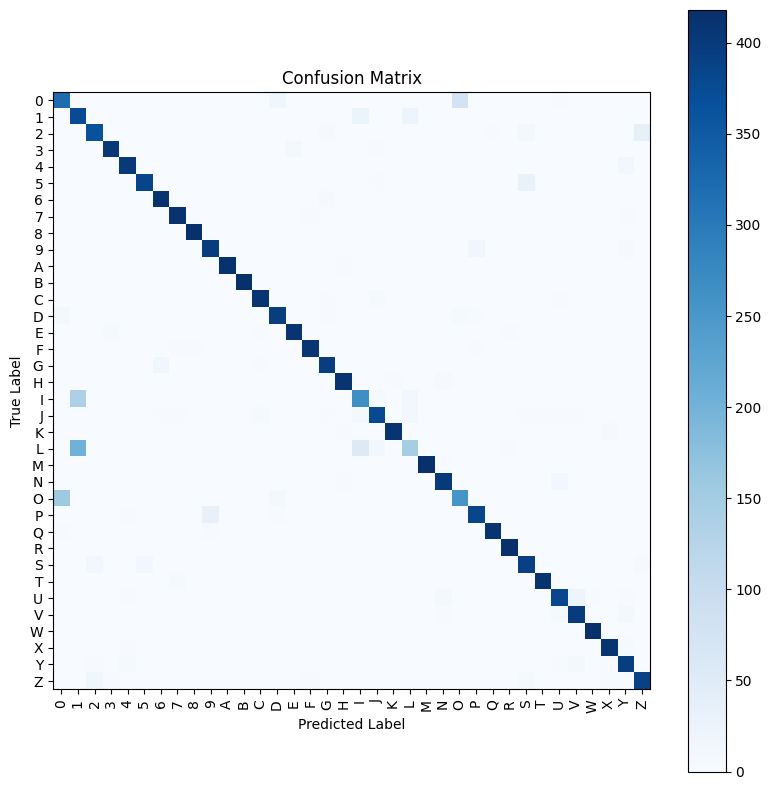

In [12]:
#Evaluating the model

# Loading the best model weights
vgg13_model.load_state_dict(torch.load(best_model_weights_path)["model_state"])
vgg13_model.eval()

#To collect all the predictionss
all_predictions, all_true_labels = [], []

with torch.no_grad():
    for input_images, true_labels in testing_loader:
        input_images, true_labels = input_images.to(compute_device), true_labels.to(compute_device)
        output_logits = vgg13_model(input_images)
        predicted_classes = output_logits.argmax(dim=1)

        all_predictions.append(predicted_classes.cpu().numpy())
        all_true_labels.append(true_labels.cpu().numpy())

all_predictions = np.concatenate(all_predictions)
all_true_labels = np.concatenate(all_true_labels)

#Accuracy
test_accuracy = (all_predictions == all_true_labels).mean()
print(f"TEST ACCURACY: {test_accuracy * 100:.2f}%")

confusion_mat = confusion_matrix(all_true_labels, all_predictions, labels=list(range(len(class_names))))
print("Classification Report:\n", classification_report(all_true_labels, all_predictions, target_names=class_names))

#Confusion matrix visualization
plt.figure(figsize=(8, 8))
plt.imshow(confusion_mat, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_positions = np.arange(len(class_names))
plt.xticks(tick_positions, class_names, rotation=90)
plt.yticks(tick_positions, class_names)
plt.tight_layout()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

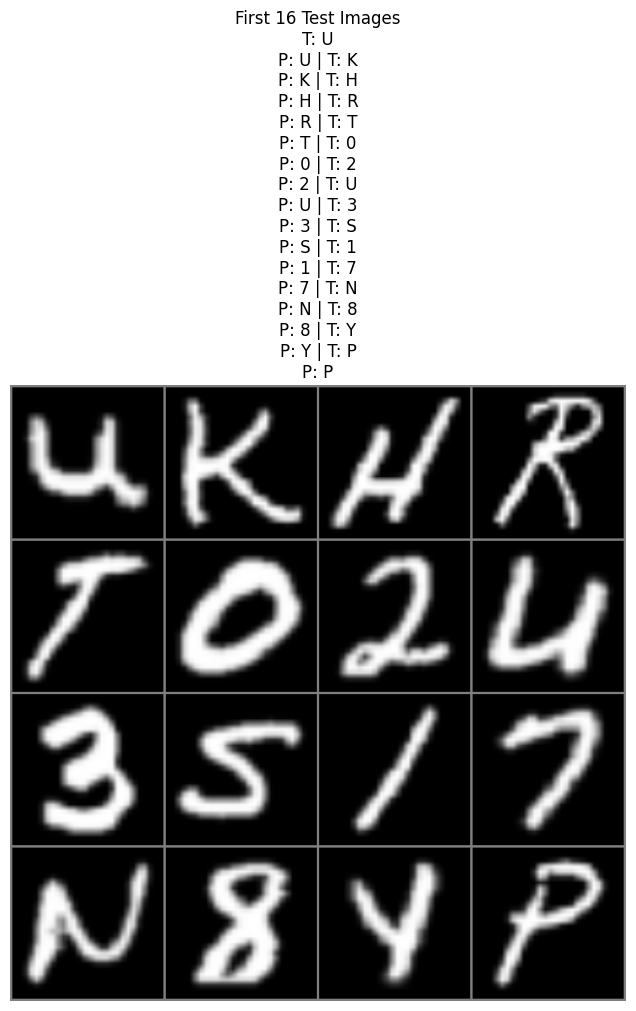

In [13]:
#displaying a batch of predictions

def show_image_grid(image_tensor, title=None):
    """Displays a grid of images with optional title."""
    img = image_tensor.clone().detach()
    img = img * 0.5 + 0.5  # Unnormalize (approx)
    np_image = img.cpu().numpy()
    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title(title if title else '')
    plt.imshow(np.transpose(np_image, (1, 2, 0)))
    plt.show()


# Fetching one batch from the test loader
test_data_iterator = iter(testing_loader)
sample_images, sample_labels = next(test_data_iterator)
sample_images = sample_images.to(compute_device)

with torch.no_grad():
    model_outputs = vgg13_model(sample_images)
predicted_labels = model_outputs.argmax(dim=1).cpu()
image_grid = make_grid(sample_images.cpu()[:16], nrow=4, padding=2)
titles = [
    f"T: {class_names[sample_labels[i]]}\nP: {class_names[predicted_labels[i]]}"
    for i in range(min(16, len(sample_labels)))
]

# Display the grid
show_image_grid(image_grid, title="First 16 Test Images\n" + " | ".join(titles))

In [14]:
import pandas as pd

#Computing TP, FP, FN, TN for each class
metrics_per_class = []
num_class_labels = len(class_names)

for class_index in range(num_class_labels):
    true_positives = confusion_mat[class_index, class_index]
    false_negatives = np.sum(confusion_mat[class_index, :]) - true_positives
    false_positives = np.sum(confusion_mat[:, class_index]) - true_positives
    true_negatives = np.sum(confusion_mat) - (true_positives + false_negatives + false_positives)

    metrics_per_class.append({
        "Class": class_names[class_index],
        "True Positives (TP)": true_positives,
        "False Negatives (FN)": false_negatives,
        "False Positives (FP)": false_positives,
        "True Negatives (TN)": true_negatives,
    })

metrics_dataframe = pd.DataFrame(metrics_per_class)
print("True Positives, False Negatives, False Positives, and True Negatives per class (One-vs-Rest):")
display(metrics_dataframe)

True Positives, False Negatives, False Positives, and True Negatives per class (One-vs-Rest):


,Class,True Positives (TP),False Negatives (FN),False Positives (FP),True Negatives (TN)
0,0,321,99,169,14531
1,1,373,47,346,14354
2,2,364,56,34,14666
3,3,404,16,11,14689
4,4,401,19,20,14680
5,5,385,35,18,14682
6,6,412,8,19,14681
7,7,412,8,15,14685
8,8,415,5,4,14696
9,9,398,22,36,14664


The above table shows the TP, FN, FP, and TN for each class, interpreted in a one-vs-rest manner. This means for each 'Class', TP counts correctly identified instances of that class, FN counts instances of that class missed by the model, FP counts instances of other classes incorrectly labeled as this class, and TN counts instances of other classes correctly identified as *not* being this class.

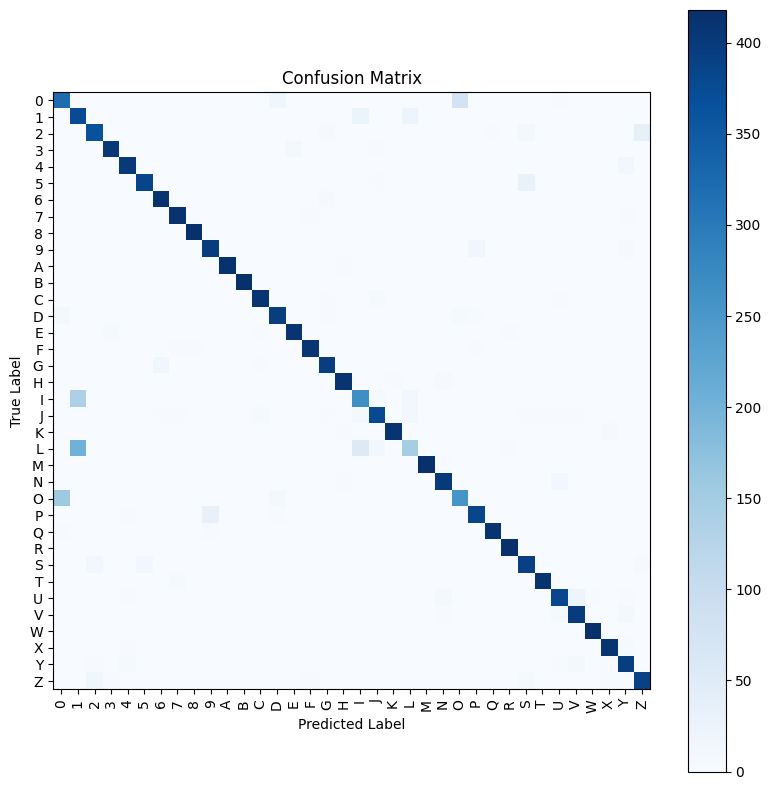

In [15]:
import matplotlib.pyplot as plt
import numpy as np

#Confusion matrix visualization
plt.figure(figsize=(8, 8))
plt.imshow(confusion_mat, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_positions = np.arange(len(class_names))
plt.xticks(tick_positions, class_names, rotation=90)
plt.yticks(tick_positions, class_names)

plt.tight_layout()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [16]:
#Calculating overall aggregate
# Summing up the one-vs-rest metrics provides an overall performance summary
aggregate_true_positives = metrics_dataframe["True Positives (TP)"].sum()
aggregate_false_negatives = metrics_dataframe["False Negatives (FN)"].sum()
aggregate_false_positives = metrics_dataframe["False Positives (FP)"].sum()
aggregate_true_negatives = metrics_dataframe["True Negatives (TN)"].sum()

print("\nAggregate Metrics (Summed Across All Classes):\n")
print(f"Total True Positives: {aggregate_true_positives}")
print(f"Total False Negatives: {aggregate_false_negatives}")
print(f"Total False Positives: {aggregate_false_positives}")
print(f"Total True Negatives: {aggregate_true_negatives}")

# Display as DataFrame
aggregate_metrics_dataframe = pd.DataFrame({
    "Metric": [
        "True Positives (TP)",
        "False Negatives (FN)",
        "False Positives (FP)",
        "True Negatives (TN)"
    ],
    "Count": [
        aggregate_true_positives,
        aggregate_false_negatives,
        aggregate_false_positives,
        aggregate_true_negatives
    ]
})

display(aggregate_metrics_dataframe)


Aggregate Metrics (Summed Across All Classes):

Total True Positives: 13815
Total False Negatives: 1305
Total False Positives: 1305
Total True Negatives: 527895


,Metric,Count
0,True Positives (TP),13815
1,False Negatives (FN),1305
2,False Positives (FP),1305
3,True Negatives (TN),527895


This aggregate view sums the individual one-vs-rest metrics for a high-level overview. For a deeper understanding of misclassifications for specific classes, refer to the `metrics_df` table above.

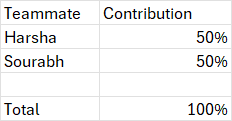

'''References:

Paper Regarding EMNIST - https://arxiv.org/pdf/1702.05373.pdf

Dataset used - https://ublearns.buffalo.edu/d2l/common/viewFile.d2lfile/Database/OTExMzM2Nw/datasets.zip?ou=317287

Pytorch tutorials - https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html

Torchinfo - https://github.com/TylerYep/torchinfo

ROC Specifications - https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc

Python Docs ( For time calculation)- https://docs.python.org/3/library/time.html

Optimizers - https://www.geeksforgeeks.org/deep-learning/optimizers-in-tensorflow/

Sci-kit learn documentation- https://scikit-learn.org/0.21/documentation.html

Seaborn documentation - https://seaborn.pydata.org/tutorial.html'''